In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
sns.set(style="whitegrid")

In [25]:
print("\n📥 Loading Dataset...")
df = pd.read_csv("air_quality.csv")

print("📌 Initial Shape:", df.shape)
print("\n📋 Dataset Info:")
print(df.info())


📥 Loading Dataset...
📌 Initial Shape: (1284, 11)

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1284 non-null   object 
 1   state          1284 non-null   object 
 2   city           1284 non-null   object 
 3   station        1284 non-null   object 
 4   last_update    1284 non-null   object 
 5   latitude       1284 non-null   float64
 6   longitude      1284 non-null   float64
 7   pollutant_id   1284 non-null   object 
 8   pollutant_min  1231 non-null   float64
 9   pollutant_max  1231 non-null   float64
 10  pollutant_avg  1231 non-null   float64
dtypes: float64(5), object(6)
memory usage: 110.5+ KB
None


In [26]:
print("\n📊 Statistical Summary:")
print(df.describe())


📊 Statistical Summary:
          latitude    longitude  pollutant_min  pollutant_max  pollutant_avg
count  1284.000000  1284.000000    1231.000000    1231.000000    1231.000000
mean     24.078360    79.397677      27.719740      93.852153      55.568643
std       5.618382     4.957602      28.823042     106.933378      60.588885
min      11.553580    70.776774       1.000000       1.000000       1.000000
25%      21.371751    76.875879       6.000000      18.000000      13.000000
50%      25.697189    77.289347      16.000000      55.000000      31.000000
75%      28.580280    83.300000      42.500000     122.000000      77.500000
max      34.066206    94.636574     188.000000     500.000000     324.000000


In [5]:
# 2️⃣ NULL & DUPLICATE CHECK
df.columns[df.isna().any()]

Index(['pollutant_min', 'pollutant_max', 'pollutant_avg'], dtype='object')

In [27]:
print("\n🔍 Missing Values:")
print(df.isnull().sum())


🔍 Missing Values:
country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
pollutant_min    53
pollutant_max    53
pollutant_avg    53
dtype: int64


In [28]:
df.fillna(df.median(numeric_only=True), inplace=True)
print("\n✅ Missing Values After Cleaning:")
print(df.isnull().sum())



✅ Missing Values After Cleaning:
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64


In [29]:
duplicates = df.duplicated().sum()
print(f"\n🗑 Duplicate Rows: {duplicates}")
df.drop_duplicates(inplace=True)



🗑 Duplicate Rows: 0


In [30]:
# 3️⃣ DATA TYPE CORRECTION
df['last_update'] = pd.to_datetime(
    df['last_update'],
    format="%d-%m-%Y %H:%M:%S",
    errors='coerce'
)


numeric_columns = [
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg',
    'latitude',
    'longitude'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
print("\n📉 Removing Outliers using Z-Score...")

z_scores = np.abs(zscore(df[numeric_columns]))
df = df[(z_scores < 3).all(axis=1)]

print("✅ Shape After Outlier Removal:", df.shape)


📉 Removing Outliers using Z-Score...
✅ Shape After Outlier Removal: (1217, 11)



📊 Distribution Analysis:

🔹 pollutant_min
Skewness : 1.387
Kurtosis : 1.282


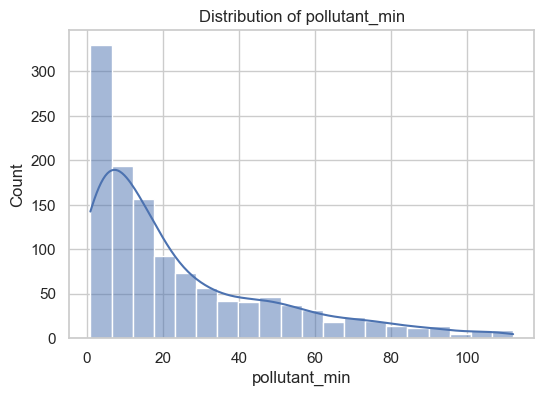


🔹 pollutant_max
Skewness : 1.776
Kurtosis : 2.954


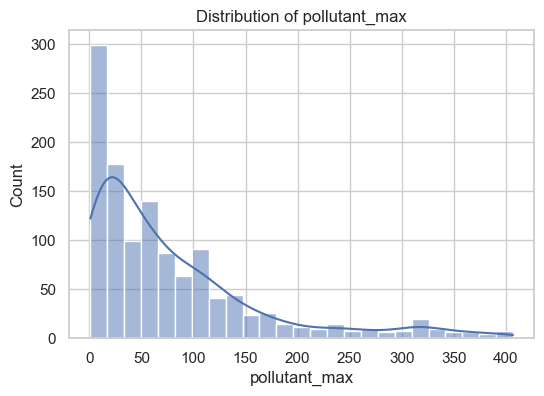


🔹 pollutant_avg
Skewness : 1.558
Kurtosis : 2.035


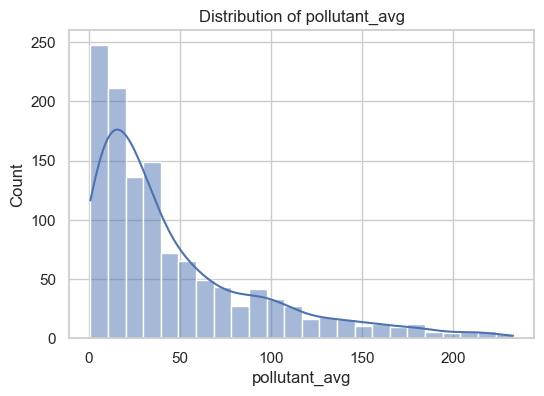


🔹 latitude
Skewness : -0.828
Kurtosis : -0.501


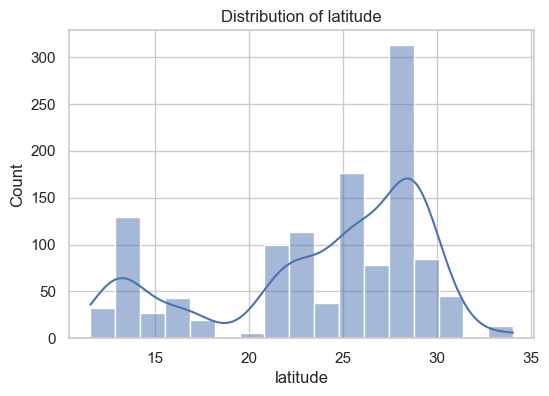


🔹 longitude
Skewness : 0.844
Kurtosis : 0.156


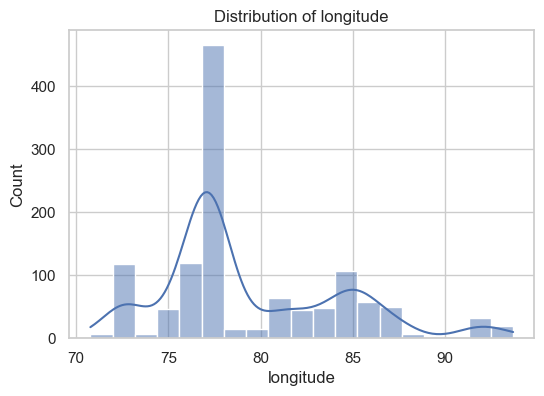

In [33]:
print("\n📊 Distribution Analysis:")

for col in numeric_columns:
    print(f"\n🔹 {col}")
    print("Skewness :", round(skew(df[col]), 3))
    print("Kurtosis :", round(kurtosis(df[col]), 3))

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [34]:
# =========================================================
# 🧠 FEATURE ENGINEERING
# =========================================================

print("\n🧠 Performing Feature Engineering...")

# ---------------------------------------------------------
# 1️⃣ Time-Based Features from Date Column
# ---------------------------------------------------------

# Convert to datetime (safe conversion)
df['last_update'] = pd.to_datetime(df['last_update'], errors='coerce')

# Extract useful parts from date
df['year'] = df['last_update'].dt.year
df['month'] = df['last_update'].dt.month
df['day'] = df['last_update'].dt.day
df['hour'] = df['last_update'].dt.hour
df['weekday'] = df['last_update'].dt.weekday  # 0 = Monday, 6 = Sunday

# Create weekend indicator (1 = Weekend, 0 = Weekday)
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

print("\n🧠 Time-Based Feature Preview:")
print(df[['last_update','year','month','day','hour','weekday','is_weekend']].head())

# Drop original datetime column after extraction
df.drop(columns=['last_update'], inplace=True)


# ---------------------------------------------------------
# 2️⃣ Pollution-Based Features
# ---------------------------------------------------------

# Difference between max and min pollution
df['pollution_range'] = df['pollutant_max'] - df['pollutant_min']

# Measures fluctuation relative to average
df['volatility_ratio'] = df['pollution_range'] / (df['pollutant_avg'] + 1)

# Relationship between minimum and maximum pollution
df['min_max_ratio'] = df['pollutant_min'] / (df['pollutant_max'] + 1)

# Average pollution relative to maximum
df['avg_max_ratio'] = df['pollutant_avg'] / (df['pollutant_max'] + 1)

print("\n🌫 Pollution-Based Feature Preview:")
print(df[['pollution_range','volatility_ratio',
          'min_max_ratio','avg_max_ratio']].head())

print("\n✅ Feature Engineering Completed Successfully!")



🧠 Performing Feature Engineering...

🧠 Time-Based Feature Preview:
          last_update  year  month  day  hour  weekday  is_weekend
0 2026-02-18 16:00:00  2026      2   18    16        2           0
1 2026-02-18 16:00:00  2026      2   18    16        2           0
2 2026-02-18 16:00:00  2026      2   18    16        2           0
3 2026-02-18 16:00:00  2026      2   18    16        2           0
4 2026-02-18 16:00:00  2026      2   18    16        2           0

🌫 Pollution-Based Feature Preview:
   pollution_range  volatility_ratio  min_max_ratio  avg_max_ratio
0              2.0          0.500000       0.500000       0.500000
1             10.0          0.454545       0.541667       0.875000
2             30.0          1.034483       0.340426       0.595745
3              0.0          0.000000       0.962963       0.962963
4              3.0          0.150000       0.800000       0.950000

✅ Feature Engineering Completed Successfully!


In [35]:

# 🌦 Create Season Feature

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df['season'] = df['month'].apply(get_season)

print("\n🌦 Season Feature Preview:")
print(df[['month','season']].head(5))



🌦 Season Feature Preview:
   month  season
0      2  Winter
1      2  Winter
2      2  Winter
3      2  Winter
4      2  Winter


In [36]:
# 🌫 Pollution Intensity Feature
df['pollution_intensity'] = pd.cut(
    df['pollution_range'],
    bins=3,
    labels=['Low','Medium','High']
)

print("\n🌫 Pollution Intensity Preview:")
print(df[['pollution_range','pollution_intensity']].head())


🌫 Pollution Intensity Preview:
   pollution_range pollution_intensity
0              2.0                 Low
1             10.0                 Low
2             30.0                 Low
3              0.0                 Low
4              3.0                 Low


In [37]:

# 🚗 Peak Hour Feature

df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if 7 <= x <= 10 or 17 <= x <= 20 else 0
)

print("\n🚗 Peak Hour Preview:")
print(df[['hour','is_peak_hour']].head())



🚗 Peak Hour Preview:
   hour  is_peak_hour
0    16             0
1    16             0
2    16             0
3    16             0
4    16             0


In [38]:
# 🌍 Absolute Latitude Feature

df['abs_latitude'] = df['latitude'].abs()

print("\n🌍 Absolute Latitude Preview:")
print(df[['latitude','abs_latitude']].head())



🌍 Absolute Latitude Preview:
    latitude  abs_latitude
0  16.536107     16.536107
1  16.536107     16.536107
2  16.536107     16.536107
3  16.536107     16.536107
4  16.486692     16.486692


In [39]:
print("Unique Years:", df['year'].unique())
print("Unique Months:", df['month'].unique())
print("Unique Weekdays:", df['weekday'].unique())
print("Weekend Values:", df['is_weekend'].unique())


Unique Years: [2026]
Unique Months: [2]
Unique Weekdays: [2]
Weekend Values: [0]


In [40]:
# 🔥 Interaction Feature


df['range_hour_interaction'] = df['pollution_range'] * df['hour']

print("\n🔥 Interaction Feature Preview:")
print(df[['pollution_range','hour','range_hour_interaction']].head())



🔥 Interaction Feature Preview:
   pollution_range  hour  range_hour_interaction
0              2.0    16                    32.0
1             10.0    16                   160.0
2             30.0    16                   480.0
3              0.0    16                     0.0
4              3.0    16                    48.0


In [41]:
# 7️⃣ TARGET CREATION
def categorize_aqi(value):
    if value <= 50:
        return "Good"
    elif value <= 100:
        return "Satisfactory"
    elif value <= 200:
        return "Moderate"
    elif value <= 300:
        return "Poor"
    else:
        return "Severe"
df['AQI_Category'] = df['pollutant_avg'].apply(categorize_aqi)

# Drop continuous version to avoid leakage
df.drop(columns=['pollutant_avg'], inplace=True)

print("\n🎯 Target Distribution:")
print(df['AQI_Category'].value_counts())


🎯 Target Distribution:
AQI_Category
Good            824
Satisfactory    228
Moderate        150
Poor             15
Name: count, dtype: int64


In [44]:
# Numeric columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter Cleaning:\n", df.isnull().sum())


After Cleaning:
 country                   0
state                     0
city                      0
station                   0
latitude                  0
longitude                 0
pollutant_id              0
pollutant_min             0
pollutant_max             0
year                      0
month                     0
day                       0
hour                      0
weekday                   0
is_weekend                0
pollution_range           0
volatility_ratio          0
min_max_ratio             0
avg_max_ratio             0
season                    0
pollution_intensity       0
is_peak_hour              0
abs_latitude              0
range_hour_interaction    0
AQI_Category              0
dtype: int64


In [75]:
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    if col != 'AQI_Category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

In [76]:
X = df.drop('AQI_Category', axis=1)
y = df['AQI_Category']


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

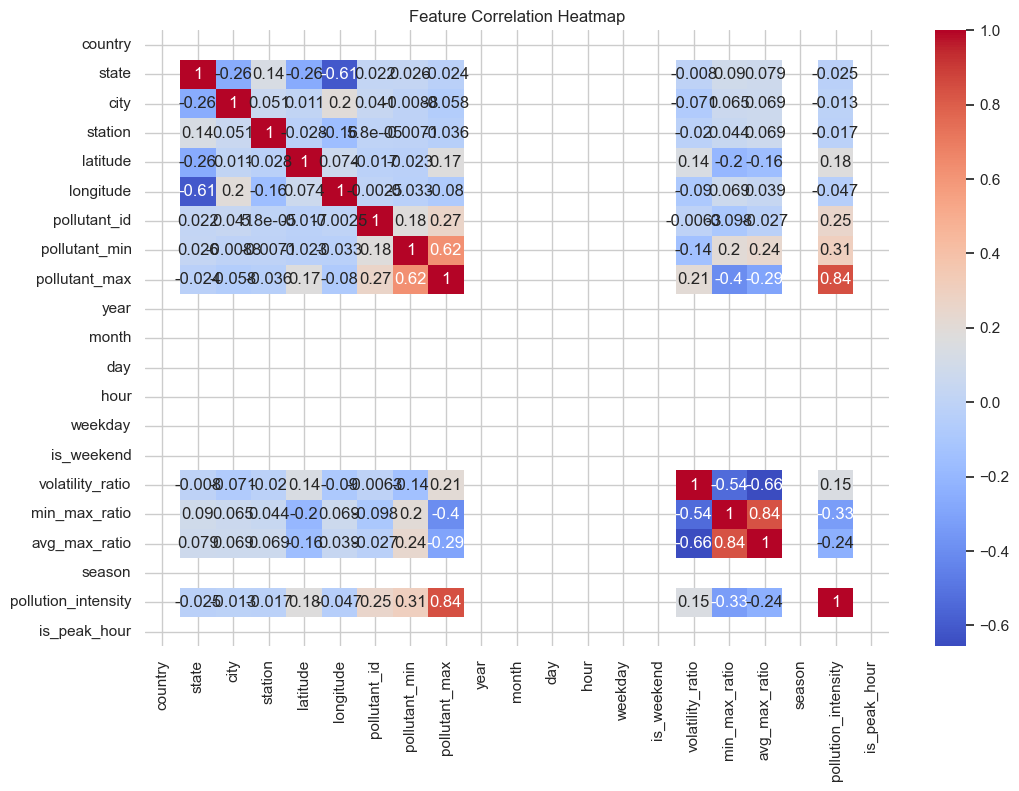

In [78]:
numeric_df = X_train.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
high_corr_features = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.90)]
X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)

# Optional: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

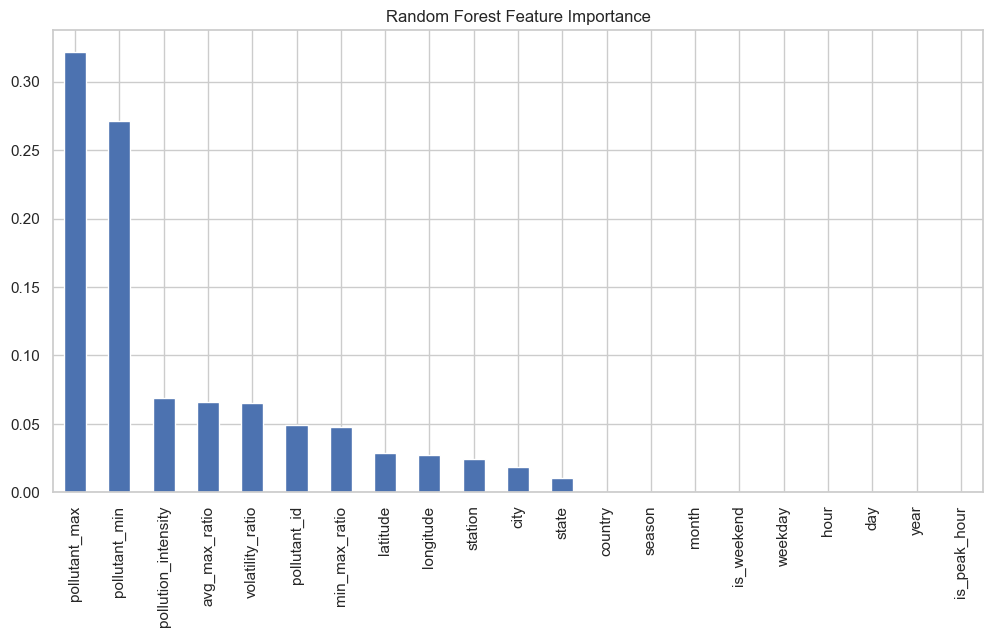

In [79]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
importances.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.show()

In [80]:

selected_features = importances[importances > 0.01].index
X_train = X_train[selected_features]
X_test = X_test[selected_features]


📌 Random Forest Accuracy: 0.9303
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       165
           1       0.86      0.83      0.85        30
           2       1.00      0.33      0.50         3
           3       0.83      0.85      0.84        46

    accuracy                           0.93       244
   macro avg       0.92      0.75      0.79       244
weighted avg       0.93      0.93      0.93       244


📌 Decision Tree Accuracy: 0.9508
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       165
           1       0.88      0.93      0.90        30
           2       0.50      0.33      0.40         3
           3       0.93      0.89      0.91        46

    accuracy                           0.95       244
   macro avg       0.82      0.78      0.80       244
weighted avg       0.95      0.95      0.95       244


📌 KNN Accuracy: 0.8730
              precision    recall  f1-

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18476\2147255536.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='viridis')


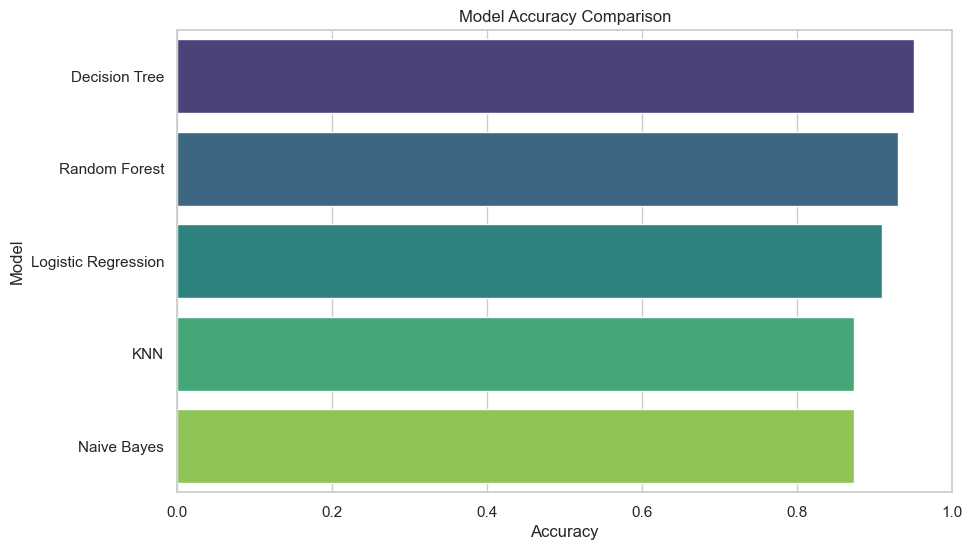

In [82]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n📌 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    results.append((name, acc))
    summary_df = pd.DataFrame(results, columns=["Model","Accuracy"]).sort_values(by="Accuracy", ascending=False)
print("\n✅ Model Comparison Table:")
print(summary_df)

# Bar Chart for Comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlim(0,1)
plt.show()